# 1 — Quickstart: super-resolve one spectrum

`specsr` takes a low-resolution JWST/NIRSpec **prism** spectrum (R~100) and predicts what the
same galaxy would look like observed with the **medium gratings** (R~1000).

This notebook runs the full chain on one real JADES galaxy and compares the prediction against
the true grating spectrum — including where it disagrees.

**What you need:** `pip install specsr[hub]`. Weights download automatically the first time.

## Load the pretrained chain

`from_pretrained()` fetches three checkpoints from the Hugging Face Hub and caches them, so
this is slow once and instant afterwards.

Three stages, all run by the pipeline:

| stage | does |
|---|---|
| **SR1** | prism → high-resolution spectrum, with a per-wavelength uncertainty |
| **ZHead** | estimates the redshift from SR1's output |
| **SR2** | refines SR1 using that redshift, fitting Gaussian line profiles at the expected positions |

SR2 is where the physics enters: knowing the redshift says *where* lines must be, so the model
fits line shapes rather than inventing features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specsr.inference import SpecSRPipeline

pipeline = SpecSRPipeline.from_pretrained()
print(pipeline.wavelength.shape, "wavelength samples,",
      f"{pipeline.wavelength[0]:.2f}-{pipeline.wavelength[-1]:.2f} um")

(6671,) wavelength samples, 1.00-5.30 um


## Load a spectrum

The repository ships a few real JADES galaxies so this runs without the full 88 GB survey tree.

> **These are held-out galaxies, and that claim is checkable.** Training augments each galaxy
> into 21 near-identical rows differing only by a small redshift shift and noise, so splitting
> such a dataset *by row* would put near-duplicates of a test galaxy into training and make every
> held-out number optimistic. The split is therefore drawn over **parent galaxies**, and
> augmentation is applied to the training side only — a held-out galaxy contributes exactly one
> row, its real observed spectrum, with no synthetic copy of it anywhere in training. Every
> galaxy in the bundled samples was checked against the split that produced the released weights:
> all of them are on the held-out side. What you see below is genuine held-out behaviour, not
> recall.

`flux_high` is the true grating spectrum. The model never sees it; we keep it only to check the
prediction.

In [2]:
data = np.load("sample_one_spectrum.npz", allow_pickle=True)

wavelength = data["wavelength"]
flux_low   = data["flux_low"]     # prism, R~100    -- the input
flux_high  = data["flux_high"]    # grating, R~1000 -- truth, for comparison only
z_true     = float(data["z"])

print(f"target {data['target_id']}  ({data['field']})")
print(f"true redshift z = {z_true:.4f}")

target 00070797  (goods-n)
true redshift z = 2.9985


## Run the model

One call. The input is standardised internally, and the output is mapped back using the
*input's* mean and standard deviation.

Our spectrum is already on the model's wavelength grid, so we don't pass `wavelength=`.
Notebook 2 covers the — much more common — case where yours is not.

In [3]:
result = pipeline(flux_low)

print("sr1:", result.sr1.shape, " sr2:", result.sr2.shape)
print(f"predicted z = {result.z[0]:.4f} +/- {result.z_sigma[0]:.4f}   (true {z_true:.4f})")

sr1: (1, 6671)  sr2: (1, 6671)
predicted z = 2.6109 +/- 0.8777   (true 2.9985)


## An important detail before plotting

The model is trained on each spectrum **standardised independently** — prism and grating each
scaled to zero mean and unit variance. So what it learns is a mapping from *shape* to *shape*.
The absolute flux scale of the grating spectrum is not recoverable from a prism spectrum alone,
and the pipeline does not pretend otherwise: it returns output on the **input's** scale.

Those two scales are not the same. Here they differ by a factor of several, and across the
validation set the median factor is ~4 and reaches past 40 on individual objects:

In [4]:
print(f"std of input prism spectrum : {np.nanstd(flux_low):.3e}")
print(f"std of true grating spectrum: {np.nanstd(flux_high):.3e}")
print(f"std of SR2 output           : {np.nanstd(result.sr2[0]):.3e}")
print(f"\nratio (true grating / SR2)  : {np.nanstd(flux_high)/np.nanstd(result.sr2[0]):.2f}x")

std of input prism spectrum : 4.637e-21
std of true grating spectrum: 1.070e-20
std of SR2 output           : 1.893e-21

ratio (true grating / SR2)  : 5.65x


So plotting them on shared axes in physical units would be comparing different scales and would
tell you nothing. Every figure in the paper is labelled $F_\lambda$ *(normalized)* for exactly
this reason, and we do the same here.

In [5]:
def standardise(x):
    """Zero mean, unit variance, NaN-aware -- the units the model actually works in."""
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x)

lr_n  = standardise(flux_low)
hr_n  = standardise(flux_high)
sr1_n = standardise(result.sr1[0])
sr2_n = standardise(result.sr2[0])

## Look at it

Full range first.

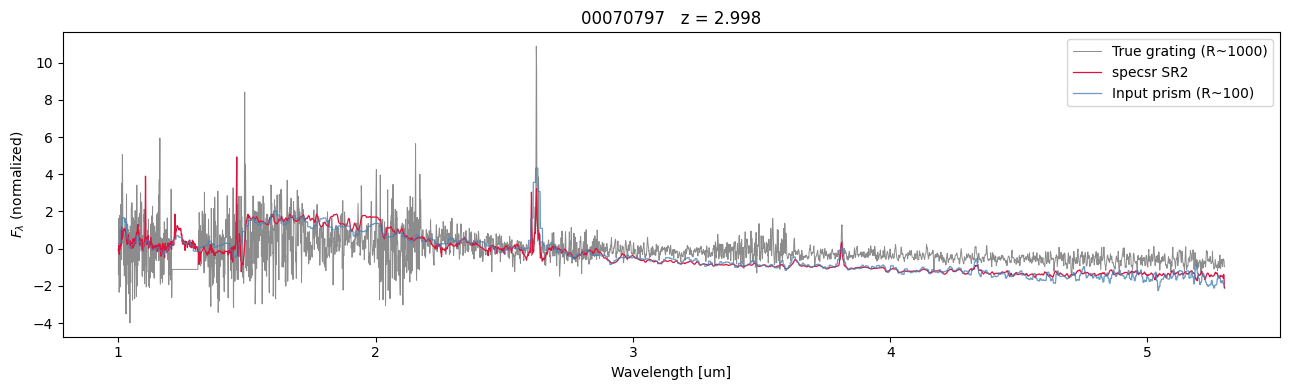

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(wavelength, hr_n,  lw=0.7, color="0.55", label="True grating (R~1000)")
ax.plot(wavelength, sr2_n, lw=0.9, color="crimson", label="specsr SR2")
ax.plot(wavelength, lr_n,  lw=0.9, color="steelblue", alpha=0.8, label="Input prism (R~100)")
ax.set_xlabel("Wavelength [um]"); ax.set_ylabel(r"$F_\lambda$ (normalized)")
ax.set_title(f"{data['target_id']}   z = {z_true:.3f}")
ax.legend(); fig.tight_layout()

## Zoom on the strongest line

This is the point of the model — and the fairest place to judge it. The shaded band is the
model's own uncertainty (rescaled by the same factor as the spectrum, so it stays meaningful).

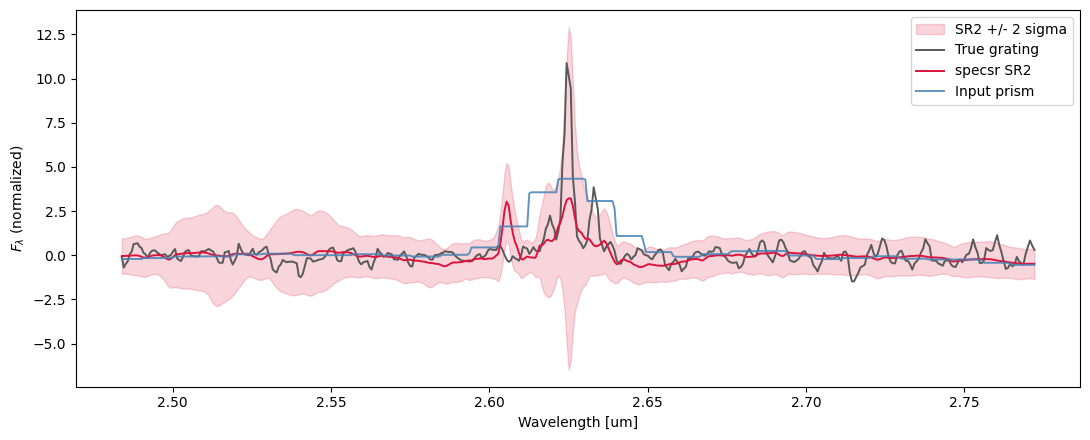

In [7]:
peak = int(np.nanargmax(np.where(np.isfinite(flux_high), flux_high, -np.inf)))
lo, hi = max(0, peak - 220), min(len(wavelength), peak + 220)
sl = slice(lo, hi)

sig_n = result.sr2_sigma[0] / np.nanstd(result.sr2[0])   # same scaling as sr2_n

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(wavelength[sl], (sr2_n - 2*sig_n)[sl], (sr2_n + 2*sig_n)[sl],
                color="crimson", alpha=0.18, label="SR2 +/- 2 sigma")
ax.plot(wavelength[sl], hr_n[sl],  lw=1.4, color="0.35", label="True grating")
ax.plot(wavelength[sl], sr2_n[sl], lw=1.4, color="crimson", label="specsr SR2")
ax.plot(wavelength[sl], lr_n[sl],  lw=1.4, color="steelblue", alpha=0.85, label="Input prism")
ax.set_xlabel("Wavelength [um]"); ax.set_ylabel(r"$F_\lambda$ (normalized)")
ax.legend(); fig.tight_layout()

Blue is what the instrument recorded; grey is what a grating observation showed; red is the
model's reconstruction from blue alone.

Judge it honestly: look at whether the *line positions* and *widths* line up, and treat
agreement in peak height as a separate and weaker claim. Notebook 3 quantifies both.

## SR1 vs SR2

SR2 is SR1 plus the physics-informed line refinement, so comparing them isolates what that
stage contributes.

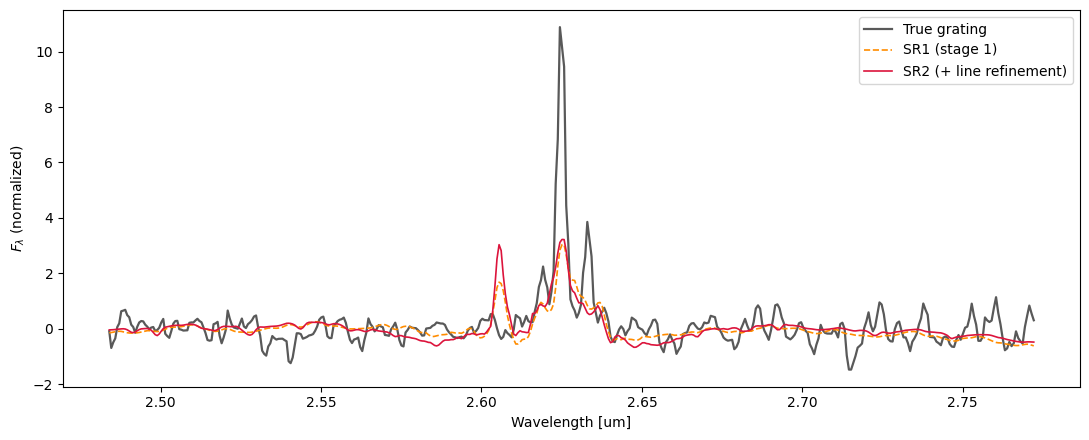

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(wavelength[sl], hr_n[sl],  lw=1.6, color="0.35", label="True grating")
ax.plot(wavelength[sl], sr1_n[sl], lw=1.2, color="darkorange", ls="--", label="SR1 (stage 1)")
ax.plot(wavelength[sl], sr2_n[sl], lw=1.2, color="crimson", label="SR2 (+ line refinement)")
ax.set_xlabel("Wavelength [um]"); ax.set_ylabel(r"$F_\lambda$ (normalized)")
ax.legend(); fig.tight_layout()

On the current checkpoints SR2 does not uniformly beat SR1 — it is measurably better at faint
lines and can be worse elsewhere. That is a known property of the released weights, not a
mistake in this notebook, and it is documented in the paper's revision notes.

## What you get back

`result` is a `SpecSRResult`:

| field | meaning |
|---|---|
| `sr1`, `sr1_sigma` | stage-1 spectrum and per-wavelength uncertainty |
| `sr2`, `sr2_sigma` | refined spectrum and uncertainty |
| `z`, `z_sigma` | redshift and its uncertainty |
| `wavelength` | output grid, microns |

Arrays are `(B, L)` for `B` spectra; scalars `(B,)`.

## Before using this scientifically

- **Absolute flux scale is not predicted.** Compare shapes, in normalized units.
- **Line flux recovery depends strongly on line brightness** — bright lines are recovered well,
  faint ones are systematically under-recovered. Notebook 3 measures this.
- **The redshift is a by-product**, not a redshift pipeline; it exists to condition SR2, its
  catastrophic-failure rate is currently high, and its hyperparameters are un-tuned.
- **Outside the training distribution, expect nonsense** — it will return a confident answer for
  input unlike anything it has seen.

Next: **notebook 2**, running the model on a spectrum on its own wavelength grid.